# DR1 catalog BAO/AP closed-blind measurements

This notebook inspects the closed DR1 catalog-level BAO/AP blinded clustering measurements produced by
`clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1.py`.

It intentionally does **not** read the private blinding bank or record. It only reads the blinded measurement products and the public-safe check summary.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import lsstypes as types

STATS_DIR = Path('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1')
CLOSED_DIR = STATS_DIR / 'data-dr1-v1.5-desiblind-bao-closed'
SUMMARY_FN = STATS_DIR / 'summary_catalog_bao_blinding_dr1.json'
PLOTS_DIR = STATS_DIR / 'plots_closed'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('closed products:', CLOSED_DIR)
print('summary:', SUMMARY_FN)
print('plots:', PLOTS_DIR)

closed products: /pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/data-dr1-v1.5-desiblind-bao-closed
summary: /pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/summary_catalog_bao_blinding_dr1.json
plots: /pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed


In [2]:
summary = json.loads(SUMMARY_FN.read_text())
df = pd.DataFrame(summary)
df['zmin'] = df['zrange'].map(lambda z: z[0])
df['zmax'] = df['zrange'].map(lambda z: z[1])
df['label'] = df.apply(lambda row: f"{row.tracer} {row.region} z={row.zmin:.1f}-{row.zmax:.1f}", axis=1)

print(f"entries: {len(df)}")
print(f"found/readable: {df.output_exists.sum()}/{len(df)} found, {df.output_readable.sum()}/{len(df)} readable")
df[['tracer', 'region', 'zrange', 'stat', 'output_readable', 'output_file']]

entries: 28
found/readable: 28/28 found, 28/28 readable


,tracer,region,zrange,stat,output_readable,output_file
0,BGS_BRIGHT-21.5,NGC,"[0.1, 0.4]",mesh2_spectrum,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
1,BGS_BRIGHT-21.5,NGC,"[0.1, 0.4]",particle2_correlation,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
2,BGS_BRIGHT-21.5,SGC,"[0.1, 0.4]",mesh2_spectrum,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
3,BGS_BRIGHT-21.5,SGC,"[0.1, 0.4]",particle2_correlation,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
4,LRG,NGC,"[0.4, 0.6]",mesh2_spectrum,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
5,LRG,NGC,"[0.4, 0.6]",particle2_correlation,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
6,LRG,SGC,"[0.4, 0.6]",mesh2_spectrum,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
7,LRG,SGC,"[0.4, 0.6]",particle2_correlation,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
8,LRG,NGC,"[0.6, 0.8]",mesh2_spectrum,True,/pscratch/sd/u/uendert/measurements_catalog_ba...
9,LRG,NGC,"[0.6, 0.8]",particle2_correlation,True,/pscratch/sd/u/uendert/measurements_catalog_ba...


In [3]:
# Public-safe attrs check. In closed mode we expect no raw w0/wa attrs.
attr_rows = []
for item in summary:
    attrs = item.get('attrs', {}) or {}
    attr_rows.append({
        'tracer': item['tracer'],
        'region': item['region'],
        'zrange': item['zrange'],
        'stat': item['stat'],
        'metadata': attrs.get('catalog_bao_blinding_metadata'),
        'source': attrs.get('catalog_bao_blinding_parameter_source'),
        'alpha_validated': attrs.get('catalog_bao_blinding_alpha_shift_validated'),
        'has_w0_attr': 'catalog_bao_blinding_w0' in attrs,
        'has_wa_attr': 'catalog_bao_blinding_wa' in attrs,
        'attrs_keys': sorted(attrs.keys()),
    })
attr_df = pd.DataFrame(attr_rows)
attr_df[['tracer', 'region', 'zrange', 'stat', 'metadata', 'source', 'alpha_validated', 'has_w0_attr', 'has_wa_attr']]

,tracer,region,zrange,stat,metadata,source,alpha_validated,has_w0_attr,has_wa_attr
0,BGS_BRIGHT-21.5,NGC,"[0.1, 0.4]",mesh2_spectrum,closed,desiblind,True,False,False
1,BGS_BRIGHT-21.5,NGC,"[0.1, 0.4]",particle2_correlation,closed,desiblind,True,False,False
2,BGS_BRIGHT-21.5,SGC,"[0.1, 0.4]",mesh2_spectrum,closed,desiblind,True,False,False
3,BGS_BRIGHT-21.5,SGC,"[0.1, 0.4]",particle2_correlation,closed,desiblind,True,False,False
4,LRG,NGC,"[0.4, 0.6]",mesh2_spectrum,closed,desiblind,True,False,False
5,LRG,NGC,"[0.4, 0.6]",particle2_correlation,closed,desiblind,True,False,False
6,LRG,SGC,"[0.4, 0.6]",mesh2_spectrum,closed,desiblind,True,False,False
7,LRG,SGC,"[0.4, 0.6]",particle2_correlation,closed,desiblind,True,False,False
8,LRG,NGC,"[0.6, 0.8]",mesh2_spectrum,closed,desiblind,True,False,False
9,LRG,NGC,"[0.6, 0.8]",particle2_correlation,closed,desiblind,True,False,False


In [4]:
assert df.output_exists.all() and df.output_readable.all()
assert not attr_df.has_w0_attr.any()
assert not attr_df.has_wa_attr.any()
print('OK: all products readable and closed attrs do not expose w0/wa.')

OK: all products readable and closed attrs do not expose w0/wa.


## Load one measurement

Use this cell to inspect one product interactively.

In [5]:
row = df.query("tracer == 'LRG' and region == 'NGC' and zmin == 0.4 and stat == 'mesh2_spectrum'").iloc[0]
obj = types.read(row.output_file)
print(row.label)
print(type(obj))
print('attrs keys containing blinding:', [key for key in getattr(obj, 'attrs', {}) if 'blinding' in key])
obj

LRG NGC z=0.4-0.6
<class 'lsstypes.types.Mesh2SpectrumPoles'>
attrs keys containing blinding: ['catalog_bao_blinding', 'catalog_bao_blinding_alpha_shift_validated', 'catalog_bao_blinding_input_zcol', 'catalog_bao_blinding_max_alpha_shift', 'catalog_bao_blinding_metadata', 'catalog_bao_blinding_mode', 'catalog_bao_blinding_output_zcol', 'catalog_bao_blinding_parameter_source']


Mesh2SpectrumPoles(labels=[{'ells': 0}, {'ells': 2}, {'ells': 4}], size=1254)

## Quick plots

The plotting calls use the `lsstypes` objects directly. The figures are also saved under `plots_closed/`.

In [6]:
def plot_one(row):
    path = Path(row.output_file)
    measurement = types.read(path)
    if row.stat == 'mesh2_spectrum':
        observable = measurement.select(k=slice(0, None, 5))
    elif row.stat == 'particle2_correlation':
        observable = measurement.select(s=slice(0, None, 4)).select(s=(20., 180.)).project(ells=[0, 2, 4])
    else:
        raise ValueError(row.stat)
    fig = observable.plot(show=False)
    if fig.axes:
        fig.axes[0].set_title(f"{row.label} closed BAO/AP blind")
    out = PLOTS_DIR / f"{row.stat}_{row.tracer}_z{row.zmin:.1f}-{row.zmax:.1f}_{row.region}.png"
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return out

# Make/update all per-product plots.
plot_files = [plot_one(row) for row in df.itertuples()]
print(f'wrote {len(plot_files)} plots to {PLOTS_DIR}')
plot_files[:5]

wrote 28 plots to /pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed


[PosixPath('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed/mesh2_spectrum_BGS_BRIGHT-21.5_z0.1-0.4_NGC.png'),
 PosixPath('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed/particle2_correlation_BGS_BRIGHT-21.5_z0.1-0.4_NGC.png'),
 PosixPath('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed/mesh2_spectrum_BGS_BRIGHT-21.5_z0.1-0.4_SGC.png'),
 PosixPath('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed/particle2_correlation_BGS_BRIGHT-21.5_z0.1-0.4_SGC.png'),
 PosixPath('/pscratch/sd/u/uendert/measurements_catalog_bao_blinding_dr1/plots_closed/mesh2_spectrum_LRG_z0.4-0.6_NGC.png')]


 mesh2_spectrum


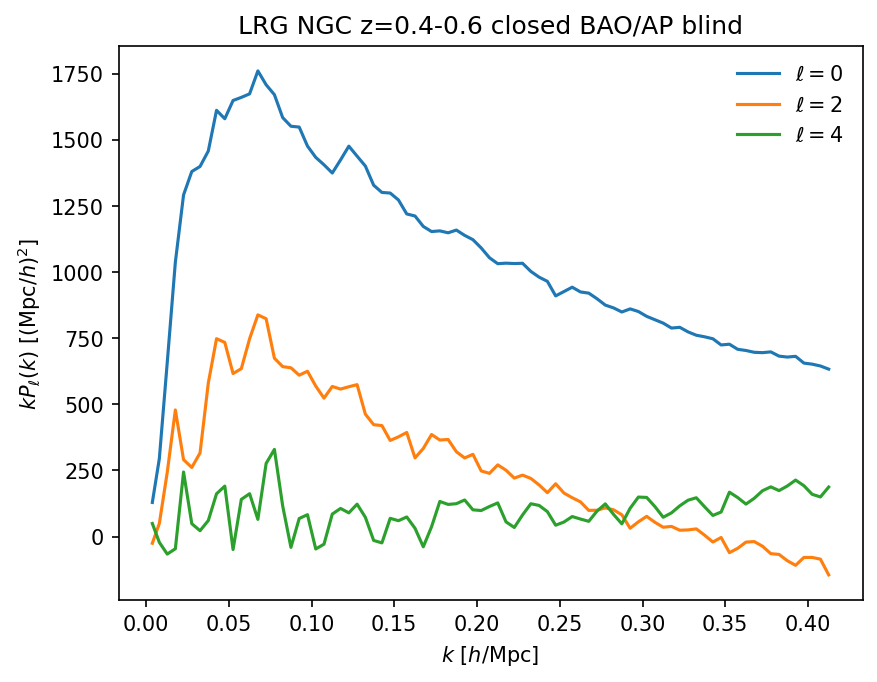

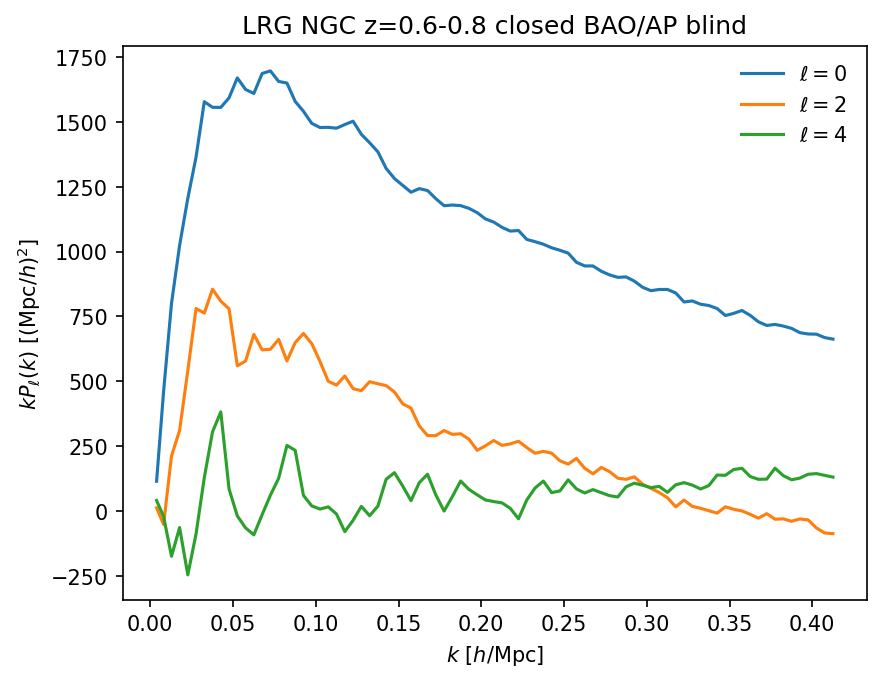

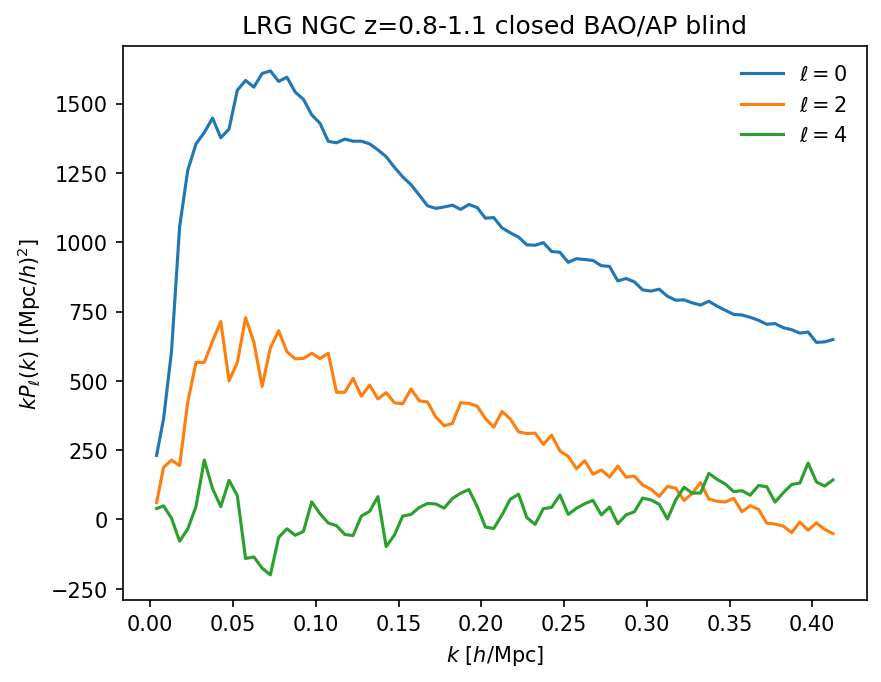


 particle2_correlation


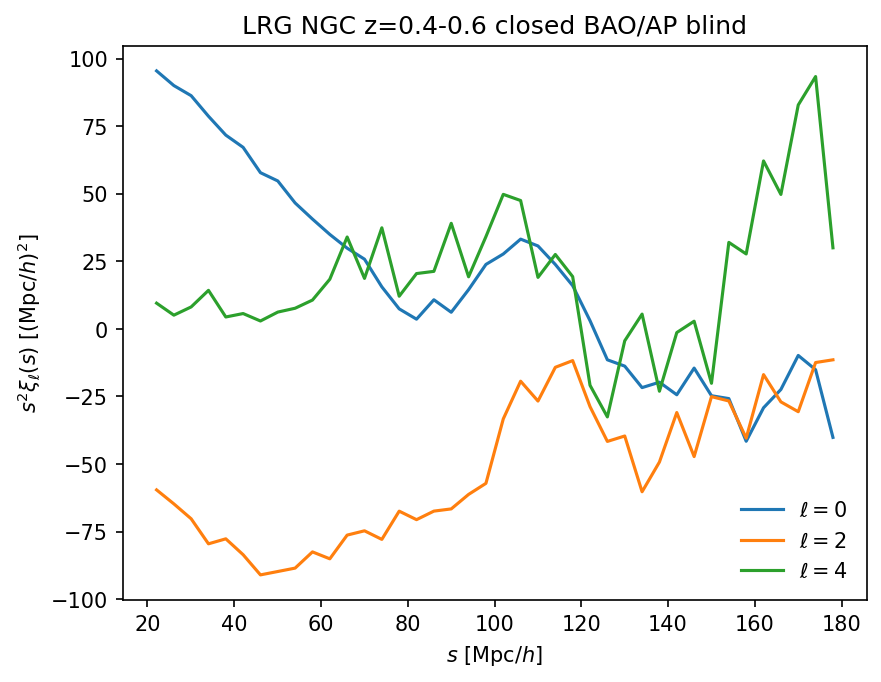

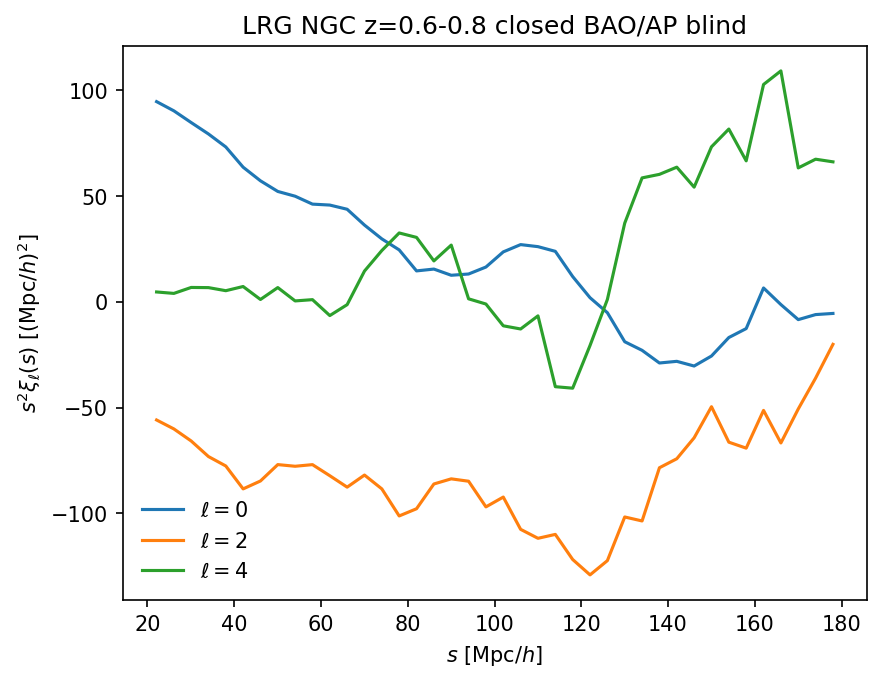

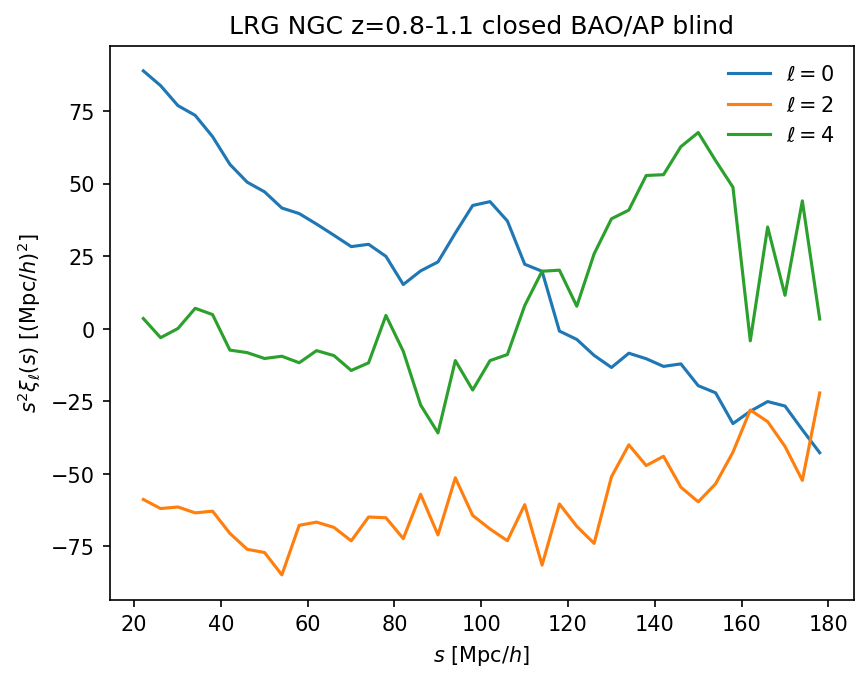

In [7]:
# Display a compact subset in the notebook.
from IPython.display import Image, display

for stat in ['mesh2_spectrum', 'particle2_correlation']:
    print('\n', stat)
    subset = df[(df.tracer == 'LRG') & (df.region == 'NGC') & (df.stat == stat)].sort_values(['zmin'])
    for row in subset.itertuples():
        png = PLOTS_DIR / f"{row.stat}_{row.tracer}_z{row.zmin:.1f}-{row.zmax:.1f}_{row.region}.png"
        display(Image(filename=str(png)))

## Notes

- These are **closed blinded** clustering statistics, not unblinded data.
- The notebook does not read `/global/cfs/cdirs/desi/users/uendert/private_blinding/...`.
- The closed output suffix is `desiblind-bao-closed`.
- Expected products: 14 tracer/region/redshift tasks × 2 statistics = 28 HDF5 files.